# 03 — EDA: Full Universe Coin Profiling

**Goal:** Profile all 66 coins in the Roostoo universe to inform strategy design.

This notebook answers:
1. Which coins have the most complete 1m data? (data quality)
2. Which coins are liquid enough to trade? (volume filter)
3. What is each coin's volatility profile? (risk sizing)
4. How correlated are the coins? (diversification)
5. What does the hourly return distribution look like? (signal design)
6. Which coins are tradeable at 1h rebalance frequency?

**DB:** `../data/ohlcv_1m.duckdb` — 1m OHLCV for 66 coins over 30 days

---

## 0. Imports & Config

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Config ──────────────────────────────────────────────────────────────
DB_PATH   = '../data/ohlcv_1m.duckdb'
INTERVAL  = '1m'

# Tradeable universe (67 coins from loader)
COINS = [
    '1000CHEEMS', 'AAVE', 'ADA', 'APT', 'ARB', 'ASTER', 'AVAX', 'AVNT',
    'BIO', 'BMT', 'BNB', 'BONK', 'BTC', 'CAKE', 'CFX', 'CRV', 'DOGE',
    'DOT', 'EDEN', 'EIGEN', 'ENA', 'ETH', 'FET', 'FIL', 'FLOKI', 'FORM',
    'HBAR', 'HEMI', 'ICP', 'LINK', 'LINEA', 'LISTA', 'LTC', 'MIRA',
    'NEAR', 'OMNI', 'ONDO', 'OPEN', 'PAXG', 'PEPE', 'PENDLE', 'PENGU',
    'PLUME', 'POL', 'PUMP', 'S', 'SEI', 'SHIB', 'SOL', 'SOMI', 'STO',
    'SUI', 'TAO', 'TON', 'TRUMP', 'TRX', 'TUT', 'UNI', 'VIRTUAL', 'WIF',
    'WLD', 'WLFI', 'XLM', 'XPL', 'XRP', 'ZEC', 'ZEN'
]
SYMBOLS = [f'{c}-USD' for c in COINS]

# Thresholds for tradeable universe filter
MIN_COMPLETENESS   = 0.80   # at least 80% of expected 1m candles present
MIN_AVG_DAILY_VOL  = 1e6    # min $1M average daily volume (in USD)
MIN_AVG_HOURLY_VOL = 5e4    # min $50k avg hourly volume

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        10,
})

print(f'Universe: {len(SYMBOLS)} coins')
print(f'DB:       {DB_PATH}')

Universe: 67 coins
DB:       ../data/ohlcv_1m.duckdb


## 1. Connect & Inspect Database

In [2]:
con = duckdb.connect(DB_PATH, read_only=True)

# Basic DB stats
total_rows = con.execute("SELECT COUNT(*) FROM ohlcv WHERE interval = '1m'").fetchone()[0]
date_range = con.execute("""
    SELECT MIN(ts)::VARCHAR, MAX(ts)::VARCHAR 
    FROM ohlcv WHERE interval = '1m'
""").fetchone()
n_symbols  = con.execute("SELECT COUNT(DISTINCT symbol) FROM ohlcv WHERE interval = '1m'").fetchone()[0]

print(f'Total 1m rows : {total_rows:,}')
print(f'Symbols found : {n_symbols}')
print(f'Date range    : {date_range[0]}  →  {date_range[1]}')

# Check which coins are present
present = con.execute("""
    SELECT DISTINCT symbol FROM ohlcv WHERE interval = '1m' ORDER BY symbol
""").df()['symbol'].tolist()

missing = [s for s in SYMBOLS if s not in present]
print(f'\nMissing from DB : {missing if missing else "None — all coins present ✓"}')

Total 1m rows : 2,851,560
Symbols found : 66
Date range    : 2026-02-16 15:11:00+08  →  2026-03-18 15:21:00+08

Missing from DB : ['OMNI-USD']


## 2. Data Completeness Analysis

Expected candles per coin = 30 days × 24h × 60min = **43,200**

Coins with < 80% completeness will be excluded from trading.

In [3]:
# Expected 1m candles over 30 days
EXPECTED_CANDLES = 30 * 24 * 60  # 43,200

completeness_df = con.execute("""
    SELECT 
        symbol,
        COUNT(*)                          AS n_candles,
        MIN(ts)::VARCHAR                  AS first_ts,
        MAX(ts)::VARCHAR                  AS last_ts,
        COUNT(*) * 1.0 / ?               AS completeness,
        COUNT(CASE WHEN volume = 0 OR volume IS NULL THEN 1 END) AS zero_vol_candles
    FROM ohlcv
    WHERE interval = '1m'
    GROUP BY symbol
    ORDER BY completeness DESC
""", [EXPECTED_CANDLES]).df()

completeness_df['completeness_pct'] = (completeness_df['completeness'] * 100).round(2)
completeness_df['tradeable']        = completeness_df['completeness'] >= MIN_COMPLETENESS

print(f"Coins with ≥ {MIN_COMPLETENESS*100:.0f}% completeness: {completeness_df['tradeable'].sum()} / {len(completeness_df)}")
print()
display(completeness_df[['symbol','n_candles','completeness_pct','zero_vol_candles','tradeable']].to_string(index=False))

Coins with ≥ 80% completeness: 66 / 66



'        symbol  n_candles  completeness_pct  zero_vol_candles  tradeable\n       ZEN-USD      43211            100.03               585       True\n       ZEC-USD      43211            100.03                 7       True\n       XPL-USD      43211            100.03              1164       True\n       XRP-USD      43211            100.03                 0       True\n      WLFI-USD      43210            100.02              1689       True\n       XLM-USD      43210            100.02               692       True\n       WIF-USD      43210            100.02             10981       True\n       WLD-USD      43210            100.02                69       True\n   VIRTUAL-USD      43210            100.02               214       True\n       UNI-USD      43210            100.02               421       True\n       TRX-USD      43209            100.02                 0       True\n       SUI-USD      43209            100.02                 5       True\n       TUT-USD      43209            

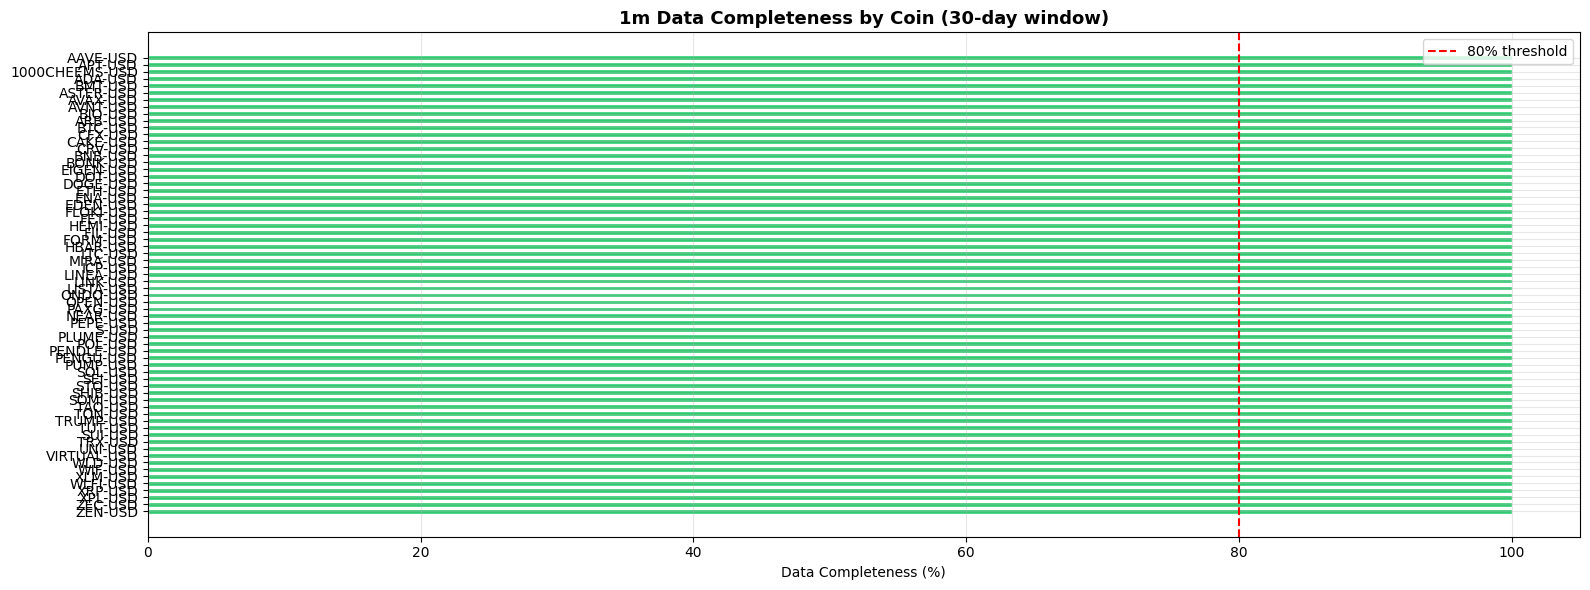

In [4]:
# Plot completeness
fig, ax = plt.subplots(figsize=(16, 6))
colors = ['#2ecc71' if t else '#e74c3c' for t in completeness_df['tradeable']]
bars = ax.barh(completeness_df['symbol'], completeness_df['completeness_pct'], color=colors, edgecolor='white', height=0.7)
ax.axvline(MIN_COMPLETENESS * 100, color='red', linestyle='--', linewidth=1.5, label=f'{MIN_COMPLETENESS*100:.0f}% threshold')
ax.set_xlabel('Data Completeness (%)')
ax.set_title('1m Data Completeness by Coin (30-day window)', fontweight='bold', fontsize=13)
ax.legend()
ax.set_xlim(0, 105)
plt.tight_layout()
plt.savefig('../data/eda_completeness.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Resample 1m → 1h

For our 1h rebalance strategy, we aggregate 1m data into hourly bars.
This is the working resolution for all signal computation.

In [5]:
# Resample all coins from 1m to 1h using DuckDB
# OHLCV aggregation: open=first, high=max, low=min, close=last, vol=sum
hourly_df = con.execute("""
    SELECT
        DATE_TRUNC('hour', ts)                  AS ts_hour,
        symbol,
        FIRST(open  ORDER BY ts)                AS open,
        MAX(high)                               AS high,
        MIN(low)                                AS low,
        LAST(close  ORDER BY ts)                AS close,
        SUM(volume)                             AS volume,
        COUNT(*)                                AS n_1m_bars
    FROM ohlcv
    WHERE interval = '1m'
    GROUP BY DATE_TRUNC('hour', ts), symbol
    ORDER BY symbol, ts_hour
""").df()

hourly_df['ts_hour'] = pd.to_datetime(hourly_df['ts_hour'], utc=True)
print(f'Hourly bars: {len(hourly_df):,}')
print(f'Expected ~: {len(SYMBOLS) * 30 * 24:,}  ({len(SYMBOLS)} coins × 30d × 24h)')
hourly_df.head(3)

Hourly bars: 47,586
Expected ~: 48,240  (67 coins × 30d × 24h)


,ts_hour,symbol,open,high,low,close,volume,n_1m_bars
0,2026-02-16 07:00:00+00:00,1000CHEEMS-USD,0.000501,0.000504,0.000499,0.000502,41593076.0,49
1,2026-02-16 08:00:00+00:00,1000CHEEMS-USD,0.000501,0.000505,0.000500,0.000503,45043342.0,60
2,2026-02-16 09:00:00+00:00,1000CHEEMS-USD,0.000503,0.000509,0.000502,0.000507,44366184.0,60


In [6]:
# Compute log returns and dollar volume for each hourly bar
hourly_df = hourly_df.sort_values(['symbol', 'ts_hour']).reset_index(drop=True)
hourly_df['log_ret']   = hourly_df.groupby('symbol')['close'].transform(lambda x: np.log(x / x.shift(1)))
hourly_df['dollar_vol'] = hourly_df['close'] * hourly_df['volume']  # volume × price ≈ USD volume

print('Hourly bars with log_ret computed:')
hourly_df[['ts_hour','symbol','close','log_ret','dollar_vol']].dropna().head(5)

Hourly bars with log_ret computed:


,ts_hour,symbol,close,log_ret,dollar_vol
1,2026-02-16 08:00:00+00:00,1000CHEEMS-USD,0.000503,0.001990,22656.801026
2,2026-02-16 09:00:00+00:00,1000CHEEMS-USD,0.000507,0.007921,22493.655288
3,2026-02-16 10:00:00+00:00,1000CHEEMS-USD,0.000509,0.003937,22334.917964
4,2026-02-16 11:00:00+00:00,1000CHEEMS-USD,0.000510,0.001963,22730.611770
5,2026-02-16 12:00:00+00:00,1000CHEEMS-USD,0.000517,0.013632,25804.699426


## 4. Liquidity Profile

Rank all coins by average **hourly dollar volume** (close × volume).
Coins with insufficient liquidity are excluded — wide spreads eat our 0.1% fee budget.

In [7]:
liquidity_df = (
    hourly_df.groupby('symbol')
    .agg(
        avg_hourly_vol_usd  = ('dollar_vol', 'mean'),
        median_hourly_vol   = ('dollar_vol', 'median'),
        avg_daily_vol_usd   = ('dollar_vol', lambda x: x.mean() * 24),
        total_hours         = ('dollar_vol', 'count'),
    )
    .reset_index()
    .sort_values('avg_hourly_vol_usd', ascending=False)
)

liquidity_df['liquid'] = liquidity_df['avg_hourly_vol_usd'] >= MIN_AVG_HOURLY_VOL
liquidity_df['avg_hourly_vol_usd_M'] = (liquidity_df['avg_hourly_vol_usd'] / 1e6).round(3)
liquidity_df['avg_daily_vol_usd_M']  = (liquidity_df['avg_daily_vol_usd']  / 1e6).round(2)

print(f"Liquid coins (avg hourly vol ≥ ${MIN_AVG_HOURLY_VOL/1e3:.0f}k): {liquidity_df['liquid'].sum()} / {len(liquidity_df)}")
print()
display(liquidity_df[['symbol','avg_hourly_vol_usd_M','avg_daily_vol_usd_M','liquid']].to_string(index=False))

Liquid coins (avg hourly vol ≥ $50k): 58 / 66



'        symbol  avg_hourly_vol_usd_M  avg_daily_vol_usd_M  liquid\n       BTC-USD                67.005              1608.12    True\n       ETH-USD                36.889               885.34    True\n       SOL-USD                12.678               304.26    True\n       XRP-USD                 8.194               196.66    True\n      DOGE-USD                 4.015                96.36    True\n       BNB-USD                 3.587                86.10    True\n      PAXG-USD                 3.378                81.08    True\n       ZEC-USD                 2.087                50.08    True\n      PEPE-USD                 1.778                42.68    True\n       SUI-USD                 1.735                41.64    True\n       ADA-USD                 1.629                39.09    True\n       TRX-USD                 1.551                37.22    True\n       TAO-USD                 1.204                28.89    True\n      LINK-USD                 1.136                27.27    

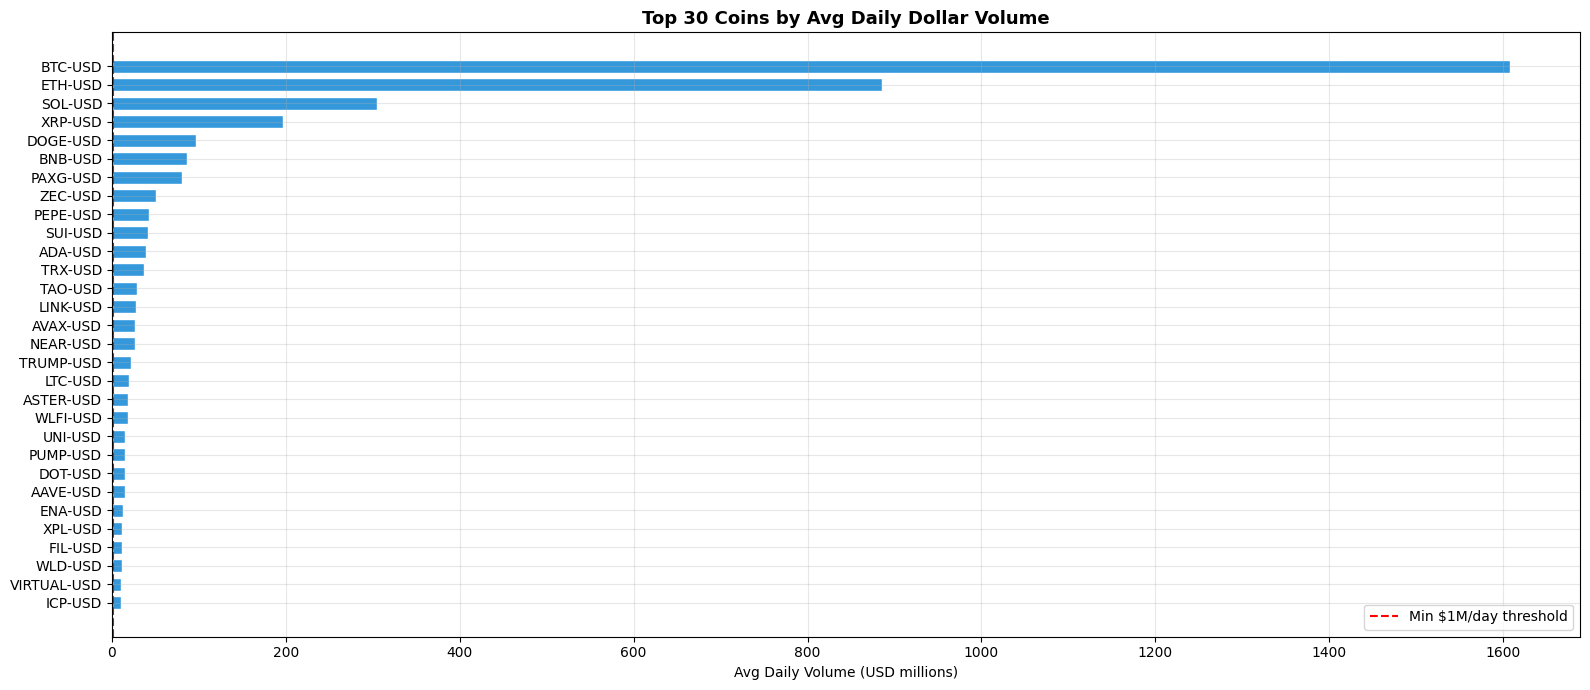

In [8]:
# Plot: Top 30 coins by liquidity
top30 = liquidity_df.head(30)
fig, ax = plt.subplots(figsize=(16, 7))
colors = ['#3498db' if l else '#bdc3c7' for l in top30['liquid']]
ax.barh(top30['symbol'][::-1], top30['avg_daily_vol_usd_M'][::-1], color=colors[::-1], edgecolor='white', height=0.7)
ax.set_xlabel('Avg Daily Volume (USD millions)')
ax.set_title('Top 30 Coins by Avg Daily Dollar Volume', fontweight='bold', fontsize=13)
ax.axvline(MIN_AVG_DAILY_VOL / 1e6, color='red', linestyle='--', linewidth=1.5, label=f'Min ${MIN_AVG_DAILY_VOL/1e6:.0f}M/day threshold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/eda_liquidity.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Volatility Profile

Measure **hourly return volatility** and **ATR (Average True Range)** per coin.

This informs:
- Position sizing (inverse-volatility weighting)
- Stop-loss levels
- Which coins have enough movement to generate alpha after fees

In [9]:
# Compute hourly ATR (true range)
hourly_df['prev_close'] = hourly_df.groupby('symbol')['close'].shift(1)
hourly_df['tr'] = np.maximum(
    hourly_df['high'] - hourly_df['low'],
    np.maximum(
        abs(hourly_df['high'] - hourly_df['prev_close']),
        abs(hourly_df['low']  - hourly_df['prev_close'])
    )
)
hourly_df['atr14'] = hourly_df.groupby('symbol')['tr'].transform(lambda x: x.rolling(14).mean())
hourly_df['atr_pct'] = hourly_df['atr14'] / hourly_df['close']  # ATR as % of price

vol_df = (
    hourly_df.dropna(subset=['log_ret'])
    .groupby('symbol')
    .agg(
        hourly_vol      = ('log_ret', 'std'),
        mean_ret        = ('log_ret', 'mean'),
        skewness        = ('log_ret', lambda x: x.skew()),
        kurtosis        = ('log_ret', lambda x: x.kurt()),
        avg_atr_pct     = ('atr_pct', 'mean'),
        max_1h_drawdown = ('log_ret', 'min'),
    )
    .reset_index()
)

vol_df['annualized_vol']  = vol_df['hourly_vol'] * np.sqrt(24 * 365)
vol_df['daily_vol']       = vol_df['hourly_vol'] * np.sqrt(24)
vol_df['hourly_vol_pct']  = (vol_df['hourly_vol'] * 100).round(4)
vol_df['daily_vol_pct']   = (vol_df['daily_vol']  * 100).round(2)
vol_df['avg_atr_pct_fmt'] = (vol_df['avg_atr_pct'] * 100).round(3)

# Naive hourly Sharpe (annualized)
vol_df['sharpe_raw'] = (vol_df['mean_ret'] / vol_df['hourly_vol'] * np.sqrt(24 * 365)).round(2)

vol_df = vol_df.sort_values('daily_vol_pct', ascending=False).reset_index(drop=True)
print('Volatility profile (sorted by daily vol):')
display(vol_df[['symbol','hourly_vol_pct','daily_vol_pct','avg_atr_pct_fmt','skewness','kurtosis','sharpe_raw']].to_string(index=False))

Volatility profile (sorted by daily vol):


'        symbol  hourly_vol_pct  daily_vol_pct  avg_atr_pct_fmt  skewness   kurtosis  sharpe_raw\n      MIRA-USD          1.9354           9.48            1.689 10.468930 201.654924       -0.50\n      FORM-USD          1.6581           8.12            1.946  0.307431  28.513989        1.63\n       STO-USD          1.4962           7.33            1.675 -1.052223  45.153886        3.01\n      EDEN-USD          1.4011           6.86            1.979  0.304382   7.333392        1.40\n       XPL-USD          1.3526           6.63            2.002 -0.043676   2.876783        1.57\n       BIO-USD          1.3235           6.48            2.019  1.390241  15.723642       -0.54\n     PLUME-USD          1.2319           6.03            1.865  0.162050   2.219960        1.18\n     TRUMP-USD          1.1828           5.79            1.517  0.572714  12.949382        0.53\n   VIRTUAL-USD          1.1634           5.70            1.720  0.895034   7.888202        2.36\n       TAO-USD          1.160

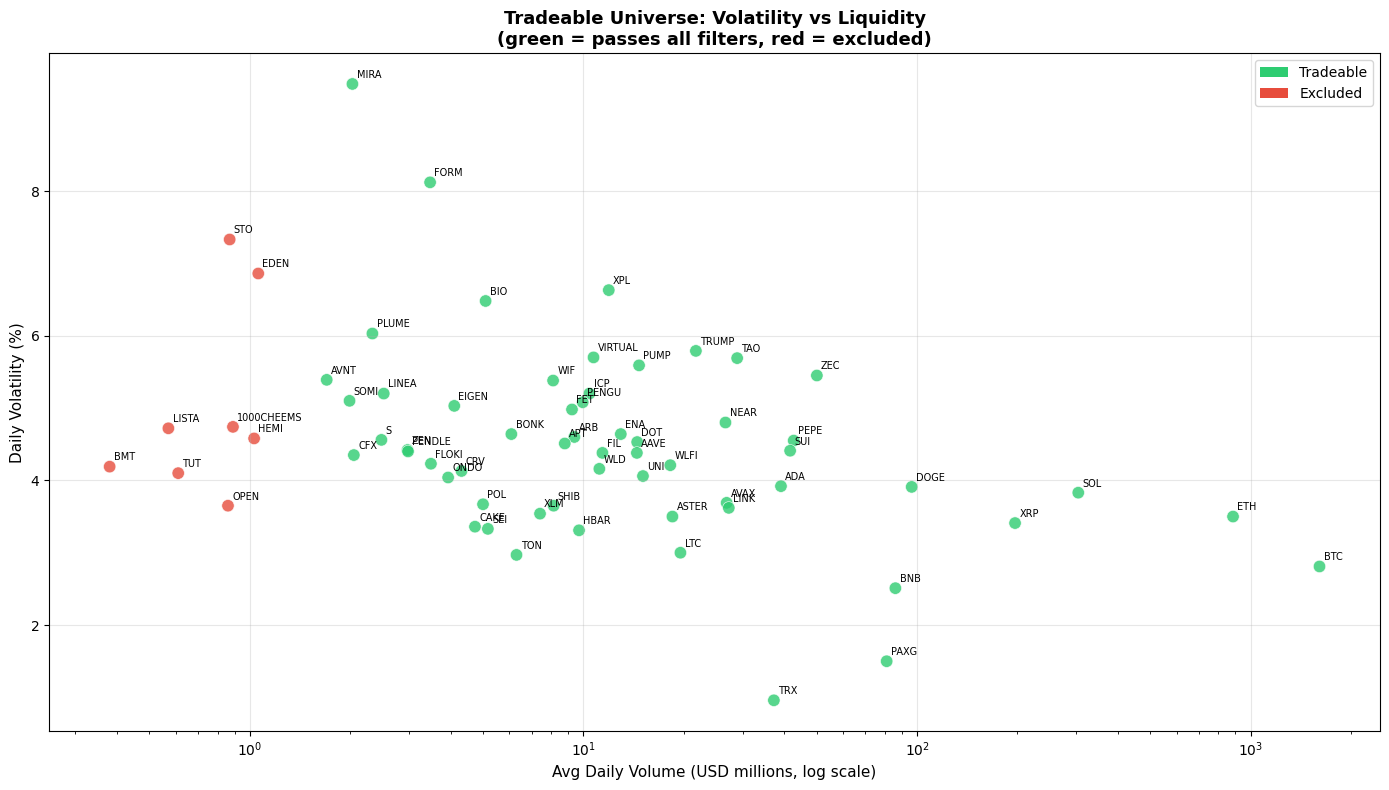


Fully tradeable coins (58):
['MIRA-USD', 'FORM-USD', 'XPL-USD', 'BIO-USD', 'PLUME-USD', 'TRUMP-USD', 'VIRTUAL-USD', 'TAO-USD', 'PUMP-USD', 'ZEC-USD', 'AVNT-USD', 'WIF-USD', 'LINEA-USD', 'ICP-USD', 'SOMI-USD', 'PENGU-USD', 'EIGEN-USD', 'FET-USD', 'NEAR-USD', 'ENA-USD', 'BONK-USD', 'ARB-USD', 'S-USD', 'PEPE-USD', 'DOT-USD', 'APT-USD', 'ZEN-USD', 'SUI-USD', 'PENDLE-USD', 'AAVE-USD', 'FIL-USD', 'CFX-USD', 'FLOKI-USD', 'WLFI-USD', 'WLD-USD', 'CRV-USD', 'UNI-USD', 'ONDO-USD', 'ADA-USD', 'DOGE-USD', 'SOL-USD', 'AVAX-USD', 'POL-USD', 'SHIB-USD', 'LINK-USD', 'XLM-USD', 'ASTER-USD', 'ETH-USD', 'XRP-USD', 'CAKE-USD', 'SEI-USD', 'HBAR-USD', 'LTC-USD', 'TON-USD', 'BTC-USD', 'BNB-USD', 'PAXG-USD', 'TRX-USD']


In [10]:
# Plot: Volatility vs Liquidity scatter — this is the key tradeable universe chart
merged = vol_df.merge(liquidity_df[['symbol','avg_daily_vol_usd_M','liquid']], on='symbol')
merged = merged.merge(completeness_df[['symbol','completeness_pct','tradeable']], on='symbol')
merged['fully_tradeable'] = merged['liquid'] & merged['tradeable']

fig, ax = plt.subplots(figsize=(14, 8))
colors = merged['fully_tradeable'].map({True: '#2ecc71', False: '#e74c3c'})
scatter = ax.scatter(
    merged['avg_daily_vol_usd_M'],
    merged['daily_vol_pct'],
    c=colors,
    s=80,
    alpha=0.8,
    edgecolors='white',
    linewidth=0.5
)
for _, row in merged.iterrows():
    ax.annotate(
        row['symbol'].replace('-USD', ''),
        (row['avg_daily_vol_usd_M'], row['daily_vol_pct']),
        fontsize=7, ha='left', va='bottom',
        xytext=(3, 3), textcoords='offset points'
    )

ax.set_xscale('log')
ax.set_xlabel('Avg Daily Volume (USD millions, log scale)', fontsize=11)
ax.set_ylabel('Daily Volatility (%)', fontsize=11)
ax.set_title('Tradeable Universe: Volatility vs Liquidity\n(green = passes all filters, red = excluded)', fontweight='bold', fontsize=13)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Tradeable'), Patch(facecolor='#e74c3c', label='Excluded')]
ax.legend(handles=legend_elements, fontsize=10)
plt.tight_layout()
plt.savefig('../data/eda_vol_vs_liquidity.png', dpi=150, bbox_inches='tight')
plt.show()

tradeable_coins = merged[merged['fully_tradeable']]['symbol'].tolist()
print(f'\nFully tradeable coins ({len(tradeable_coins)}):')
print(tradeable_coins)

## 6. Return Distribution Analysis

Understand the shape of hourly returns per coin.

Key questions:
- Are returns fat-tailed? (affects stop-loss sizing)
- Are returns skewed? (momentum vs mean-reversion bias)
- What % of hours move > 1%? (signal frequency)

In [11]:
# Distribution stats for tradeable coins only
tradeable_df = hourly_df[hourly_df['symbol'].isin(tradeable_coins)].dropna(subset=['log_ret'])

dist_df = (
    tradeable_df.groupby('symbol')['log_ret']
    .agg(
        p1   = lambda x: np.percentile(x, 1),
        p5   = lambda x: np.percentile(x, 5),
        p25  = lambda x: np.percentile(x, 25),
        p50  = lambda x: np.percentile(x, 50),
        p75  = lambda x: np.percentile(x, 75),
        p95  = lambda x: np.percentile(x, 95),
        p99  = lambda x: np.percentile(x, 99),
        pct_up_1pct   = lambda x: (x > 0.01).mean() * 100,
        pct_down_1pct = lambda x: (x < -0.01).mean() * 100,
    )
    .reset_index()
    .round(4)
)

print('Return percentiles (log returns) for tradeable coins:')
display(dist_df.to_string(index=False))

Return percentiles (log returns) for tradeable coins:


'     symbol      p1      p5     p25     p50    p75    p95    p99  pct_up_1pct  pct_down_1pct\n   AAVE-USD -0.0197 -0.0131 -0.0047 -0.0003 0.0045 0.0142 0.0238       9.7222         9.4444\n    ADA-USD -0.0202 -0.0111 -0.0039 -0.0004 0.0035 0.0129 0.0251       8.0556         6.5278\n    APT-USD -0.0231 -0.0138 -0.0046  0.0000 0.0042 0.0147 0.0258      11.3889         9.4444\n    ARB-USD -0.0230 -0.0136 -0.0051  0.0000 0.0048 0.0139 0.0267      10.5556         9.5833\n  ASTER-USD -0.0211 -0.0111 -0.0029  0.0000 0.0042 0.0113 0.0189       5.8333         5.4167\n   AVAX-USD -0.0171 -0.0101 -0.0041  0.0000 0.0033 0.0118 0.0240       7.2222         5.2778\n   AVNT-USD -0.0228 -0.0155 -0.0058 -0.0005 0.0045 0.0145 0.0269      10.5556        11.8056\n    BIO-USD -0.0319 -0.0188 -0.0049  0.0000 0.0048 0.0162 0.0394      11.1111        12.7778\n    BNB-USD -0.0124 -0.0079 -0.0026  0.0001 0.0029 0.0080 0.0135       3.0556         2.2222\n   BONK-USD -0.0229 -0.0141 -0.0050  0.0000 0.0049 0.0149 0

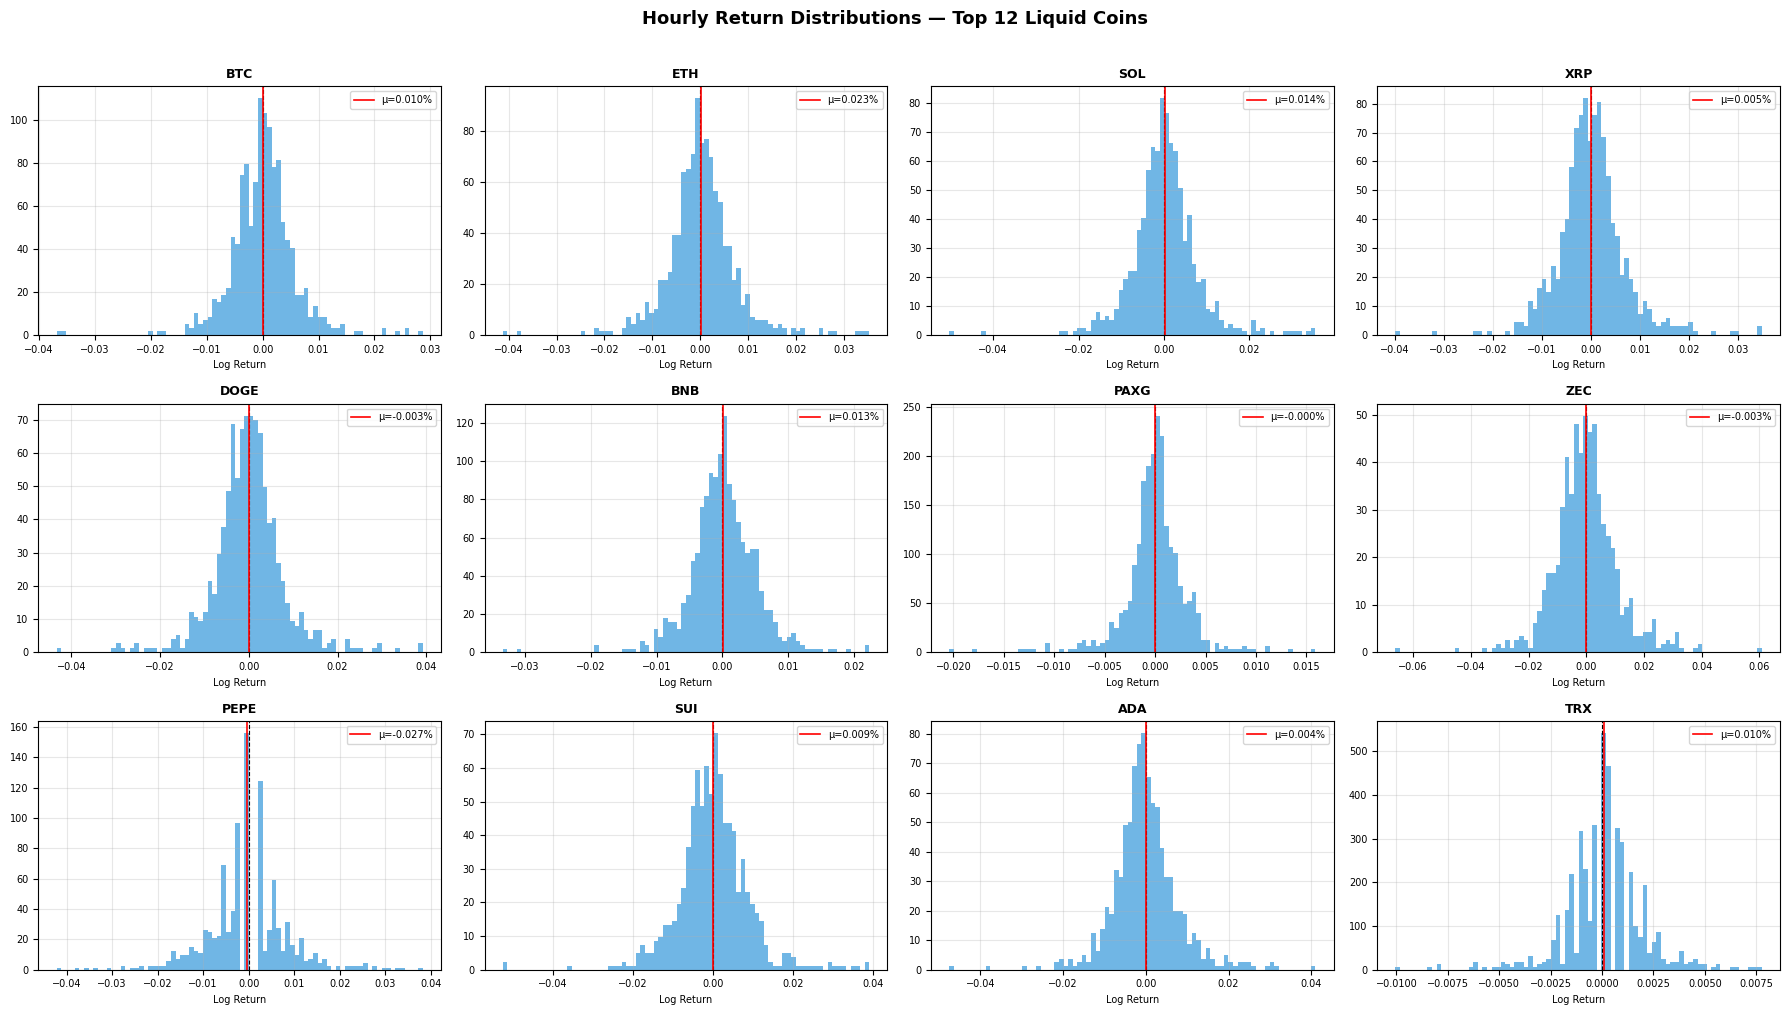

In [12]:
# Plot: Return distributions for top 12 liquid coins
top12_liquid = liquidity_df[liquidity_df['symbol'].isin(tradeable_coins)].head(12)['symbol'].tolist()

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()

for i, sym in enumerate(top12_liquid):
    rets = tradeable_df[tradeable_df['symbol'] == sym]['log_ret'].dropna()
    ax = axes[i]
    ax.hist(rets, bins=80, color='#3498db', alpha=0.7, edgecolor='none', density=True)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(rets.mean(), color='red', linewidth=1.2, linestyle='-', label=f'μ={rets.mean()*100:.3f}%')
    ax.set_title(sym.replace('-USD', ''), fontweight='bold', fontsize=9)
    ax.set_xlabel('Log Return', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

plt.suptitle('Hourly Return Distributions — Top 12 Liquid Coins', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../data/eda_return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Correlation Matrix

Understand how coins co-move. High correlation = low diversification benefit.

We want to hold coins that **move somewhat independently** to smooth the portfolio equity curve.

In [13]:
# Pivot to wide format: rows=timestamps, cols=symbols
pivot = (
    hourly_df[hourly_df['symbol'].isin(tradeable_coins)]
    .dropna(subset=['log_ret'])
    .pivot_table(index='ts_hour', columns='symbol', values='log_ret')
)

# Drop timestamps where fewer than 50% of coins have data
pivot = pivot.dropna(thresh=int(len(tradeable_coins) * 0.5))

corr_matrix = pivot.corr()
print(f'Correlation matrix shape: {corr_matrix.shape}')
print(f'Timestamps used         : {len(pivot)}')

# Summary stats
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
flat_corrs = upper_tri.values.flatten()
flat_corrs = flat_corrs[~np.isnan(flat_corrs)]
print(f'\nPairwise correlation stats:')
print(f'  Mean   : {flat_corrs.mean():.3f}')
print(f'  Median : {np.median(flat_corrs):.3f}')
print(f'  Std    : {flat_corrs.std():.3f}')
print(f'  > 0.8  : {(flat_corrs > 0.8).sum()} pairs')
print(f'  < 0.3  : {(flat_corrs < 0.3).sum()} pairs  ← good diversifiers')

Correlation matrix shape: (58, 58)
Timestamps used         : 720

Pairwise correlation stats:
  Mean   : 0.564
  Median : 0.607
  Std    : 0.203
  > 0.8  : 141 pairs
  < 0.3  : 211 pairs  ← good diversifiers


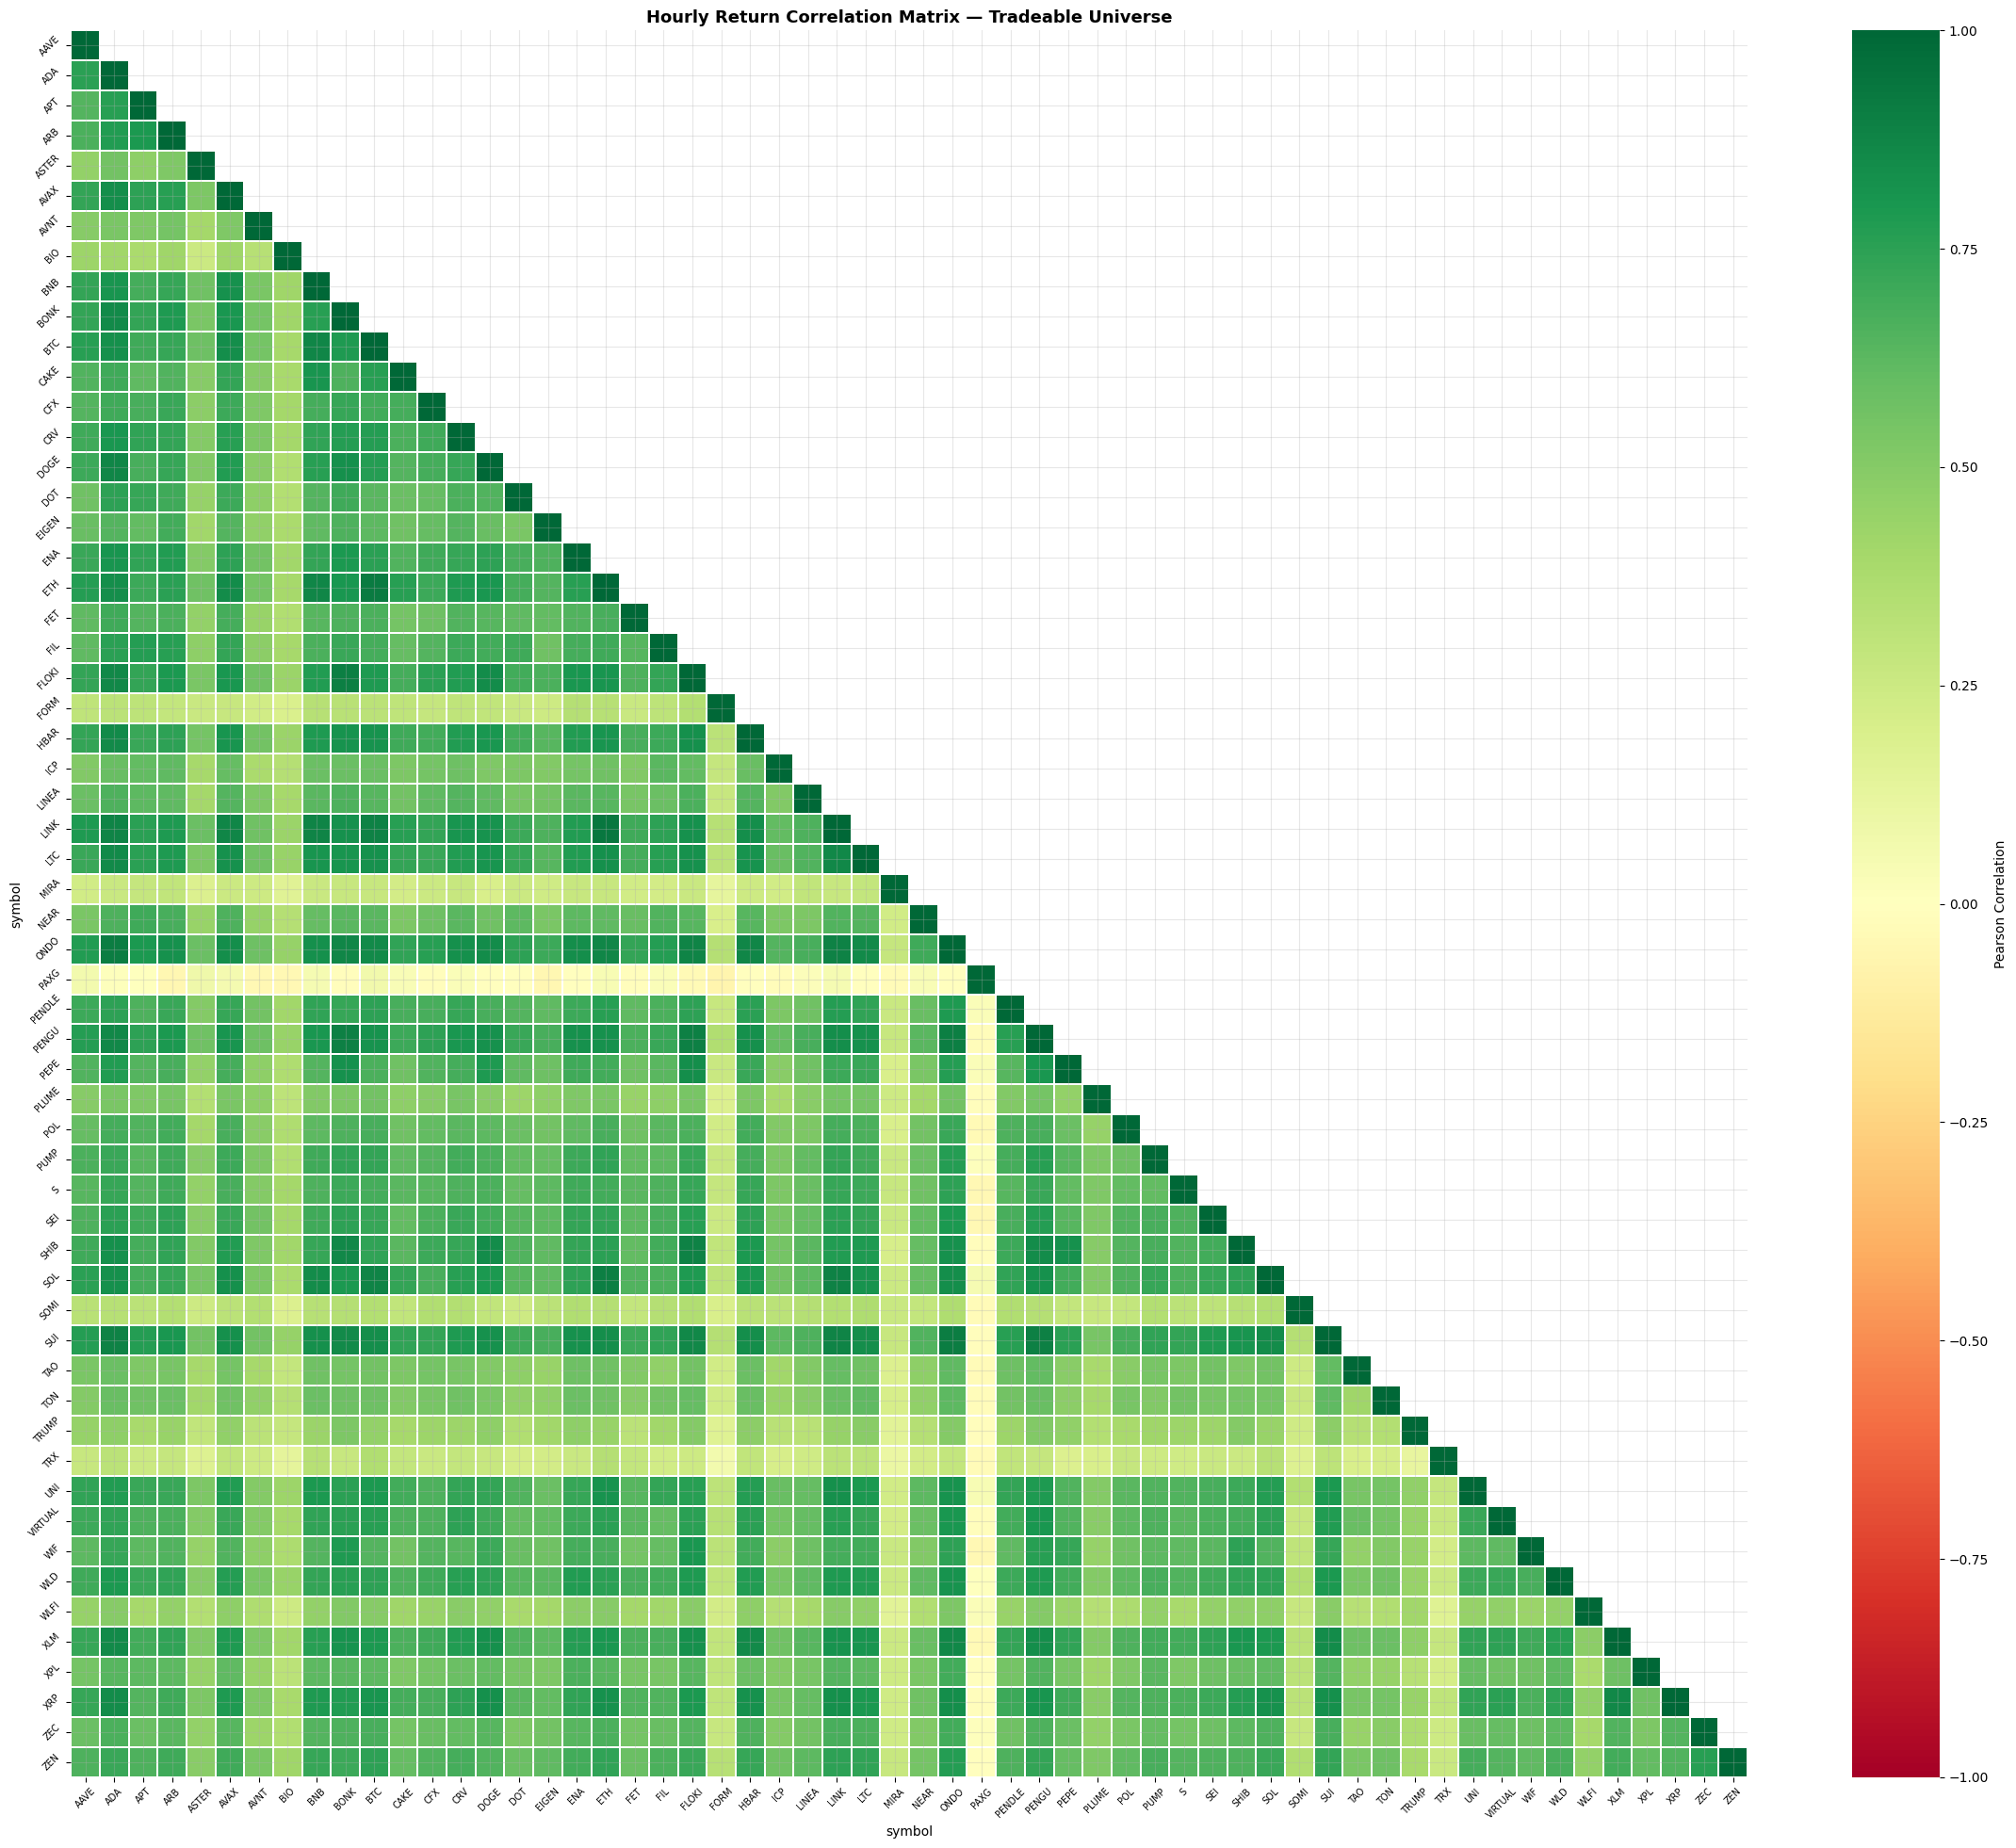

In [14]:
# Plot correlation heatmap
n = len(corr_matrix)
fig_size = max(12, n * 0.4)
fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.85))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    annot=(n <= 20),  # only annotate if small enough
    fmt='.2f',
    linewidths=0.3,
    ax=ax,
    cbar_kws={'label': 'Pearson Correlation'},
    xticklabels=[s.replace('-USD','') for s in corr_matrix.columns],
    yticklabels=[s.replace('-USD','') for s in corr_matrix.index],
)
ax.set_title('Hourly Return Correlation Matrix — Tradeable Universe', fontweight='bold', fontsize=13)
ax.tick_params(labelsize=7, rotation=45)
plt.tight_layout()
plt.savefig('../data/eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Volume-of-Day (VoD) Profile

Understand **when** coins are most liquid across the 24h cycle.

Our 1h rebalance should ideally execute during **high-volume hours** to get better fills.

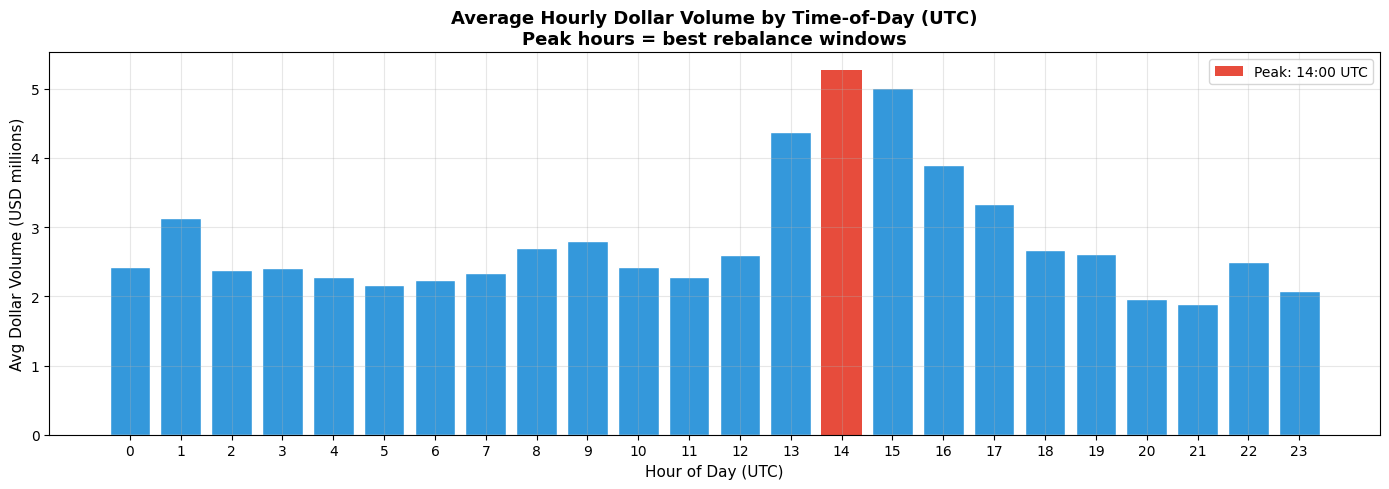

Top 5 highest-volume hours (UTC):
  14:00 UTC  →  $5.27M avg
  15:00 UTC  →  $5.02M avg
  13:00 UTC  →  $4.37M avg
  16:00 UTC  →  $3.90M avg
  17:00 UTC  →  $3.34M avg


In [15]:
hourly_df['hour_utc'] = hourly_df['ts_hour'].dt.hour

# Aggregate dollar volume by hour-of-day for tradeable coins
vod = (
    hourly_df[hourly_df['symbol'].isin(tradeable_coins)]
    .groupby(['hour_utc', 'symbol'])['dollar_vol']
    .mean()
    .reset_index()
    .groupby('hour_utc')['dollar_vol']
    .mean()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(vod.index, vod.values / 1e6, color='#3498db', edgecolor='white', width=0.8)
ax.set_xlabel('Hour of Day (UTC)', fontsize=11)
ax.set_ylabel('Avg Dollar Volume (USD millions)', fontsize=11)
ax.set_title('Average Hourly Dollar Volume by Time-of-Day (UTC)\nPeak hours = best rebalance windows', fontweight='bold', fontsize=13)
ax.set_xticks(range(24))

# Highlight peak hours
peak_hour = int(vod.idxmax())
ax.bar(peak_hour, vod[peak_hour] / 1e6, color='#e74c3c', label=f'Peak: {peak_hour:02d}:00 UTC')
ax.legend()
plt.tight_layout()
plt.savefig('../data/eda_volume_of_day.png', dpi=150, bbox_inches='tight')
plt.show()

top5_hours = vod.nlargest(5)
print('Top 5 highest-volume hours (UTC):')
for h, v in top5_hours.items():
    print(f'  {h:02d}:00 UTC  →  ${v/1e6:.2f}M avg')

## 9. Momentum Signal Preview

Early signal quality check: does short-term momentum **persist** or **revert** at 1h frequency?

We compute **autocorrelation of hourly returns** for each coin.
- Positive AC(1) → momentum tendency → trend-following signals work
- Negative AC(1) → mean-reversion tendency → fade signals work

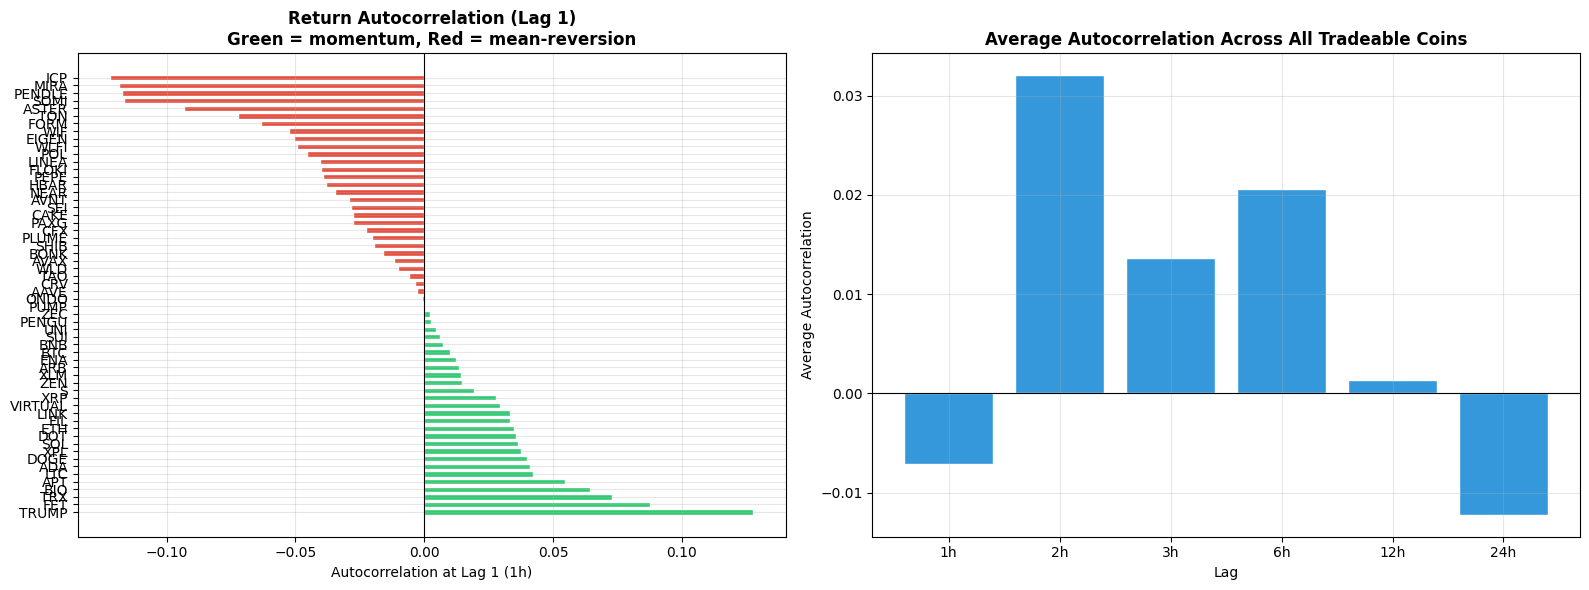


Momentum vs Mean-Reversion summary:
  Coins with positive AC(1) (momentum-friendly) : 28
  Coins with negative AC(1) (mean-reversion)    : 30
  Universe avg AC(1)                            : -0.0072


In [ ]:
autocorr_df = []
for sym in tradeable_coins:
    rets = hourly_df[hourly_df['symbol'] == sym]['log_ret'].dropna()
    if len(rets) < 50:
        continue
    autocorr_df.append({
        'symbol' : sym,
        'ac1'    : rets.autocorr(lag=1),
        'ac2'    : rets.autocorr(lag=2),
        'ac3'    : rets.autocorr(lag=3),
        'ac6'    : rets.autocorr(lag=6),
        'ac12'   : rets.autocorr(lag=12),
        'ac24'   : rets.autocorr(lag=24),
    })

autocorr_df = pd.DataFrame(autocorr_df).sort_values('ac1', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# AC(1) bar chart
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in autocorr_df['ac1']]
axes[0].barh(autocorr_df['symbol'].str.replace('-USD',''), autocorr_df['ac1'], color=colors, edgecolor='white', height=0.7)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Autocorrelation at Lag 1 (1h)')
axes[0].set_title('Return Autocorrelation (Lag 1)\nGreen = momentum, Red = mean-reversion', fontweight='bold')

# Average AC across lags
avg_ac = autocorr_df[['ac1','ac2','ac3','ac6','ac12','ac24']].mean()
axes[1].bar(['1h','2h','3h','6h','12h','24h'], avg_ac.values, color='#3498db', edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Average Autocorrelation')
axes[1].set_title('Average Autocorrelation Across All Tradeable Coins', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/eda_autocorrelation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMomentum vs Mean-Reversion summary:')
print(f'  Coins with positive AC(1) (momentum-friendly) : {(autocorr_df["ac1"] > 0).sum()}')
print(f'  Coins with negative AC(1) (mean-reversion)    : {(autocorr_df["ac1"] < 0).sum()}')
print(f'  Universe avg AC(1)                            : {autocorr_df["ac1"].mean():.4f}')

## 10. Cross-Sectional Momentum Preview

Rank coins by their **N-hour return** at each hourly timestamp.
Check whether top-ranked coins over the past N hours **outperform** over the next 1h.

This is the core signal hypothesis test.

In [17]:
LOOKBACK_HOURS = [4, 8, 12, 24]  # momentum lookback windows to test

results = []

for lb in LOOKBACK_HOURS:
    # For each coin, compute rolling lb-hour return
    pivot_close = (
        hourly_df[hourly_df['symbol'].isin(tradeable_coins)]
        .pivot_table(index='ts_hour', columns='symbol', values='close')
        .sort_index()
    )
    
    mom = pivot_close.pct_change(lb)           # lookback return (signal)
    fwd = pivot_close.pct_change(1).shift(-1)  # next 1h return (outcome)

    # At each timestamp, rank coins by momentum (1=lowest, N=highest)
    ranks = mom.rank(axis=1, pct=True)  # percentile rank 0..1

    # Top quintile (top 20%) vs Bottom quintile (bottom 20%)
    top_q    = fwd.where(ranks >= 0.8).mean(axis=1)  # avg return of top 20%
    bot_q    = fwd.where(ranks <= 0.2).mean(axis=1)  # avg return of bot 20%
    ls_spread = top_q - bot_q                         # long-short spread

    results.append({
        'lookback_h'          : lb,
        'top_quintile_mean'   : top_q.mean() * 100,
        'bot_quintile_mean'   : bot_q.mean() * 100,
        'ls_spread_mean'      : ls_spread.mean() * 100,
        'top_quintile_sharpe' : top_q.mean() / top_q.std() * np.sqrt(24 * 365) if top_q.std() > 0 else 0,
        'hit_rate_top'        : (top_q > 0).mean() * 100,
    })

results_df = pd.DataFrame(results)
print('Cross-sectional momentum: Top quintile vs Bottom quintile (next 1h return):')
print()
display(results_df.round(4).to_string(index=False))

Cross-sectional momentum: Top quintile vs Bottom quintile (next 1h return):



' lookback_h  top_quintile_mean  bot_quintile_mean  ls_spread_mean  top_quintile_sharpe  hit_rate_top\n          4             0.0053             0.0142         -0.0089               0.6275       46.6019\n          8             0.0163             0.0138          0.0025               1.9398       49.5146\n         12             0.0098             0.0134         -0.0036               1.1888       49.3759\n         24            -0.0090             0.0155         -0.0245              -1.1063       47.5728'

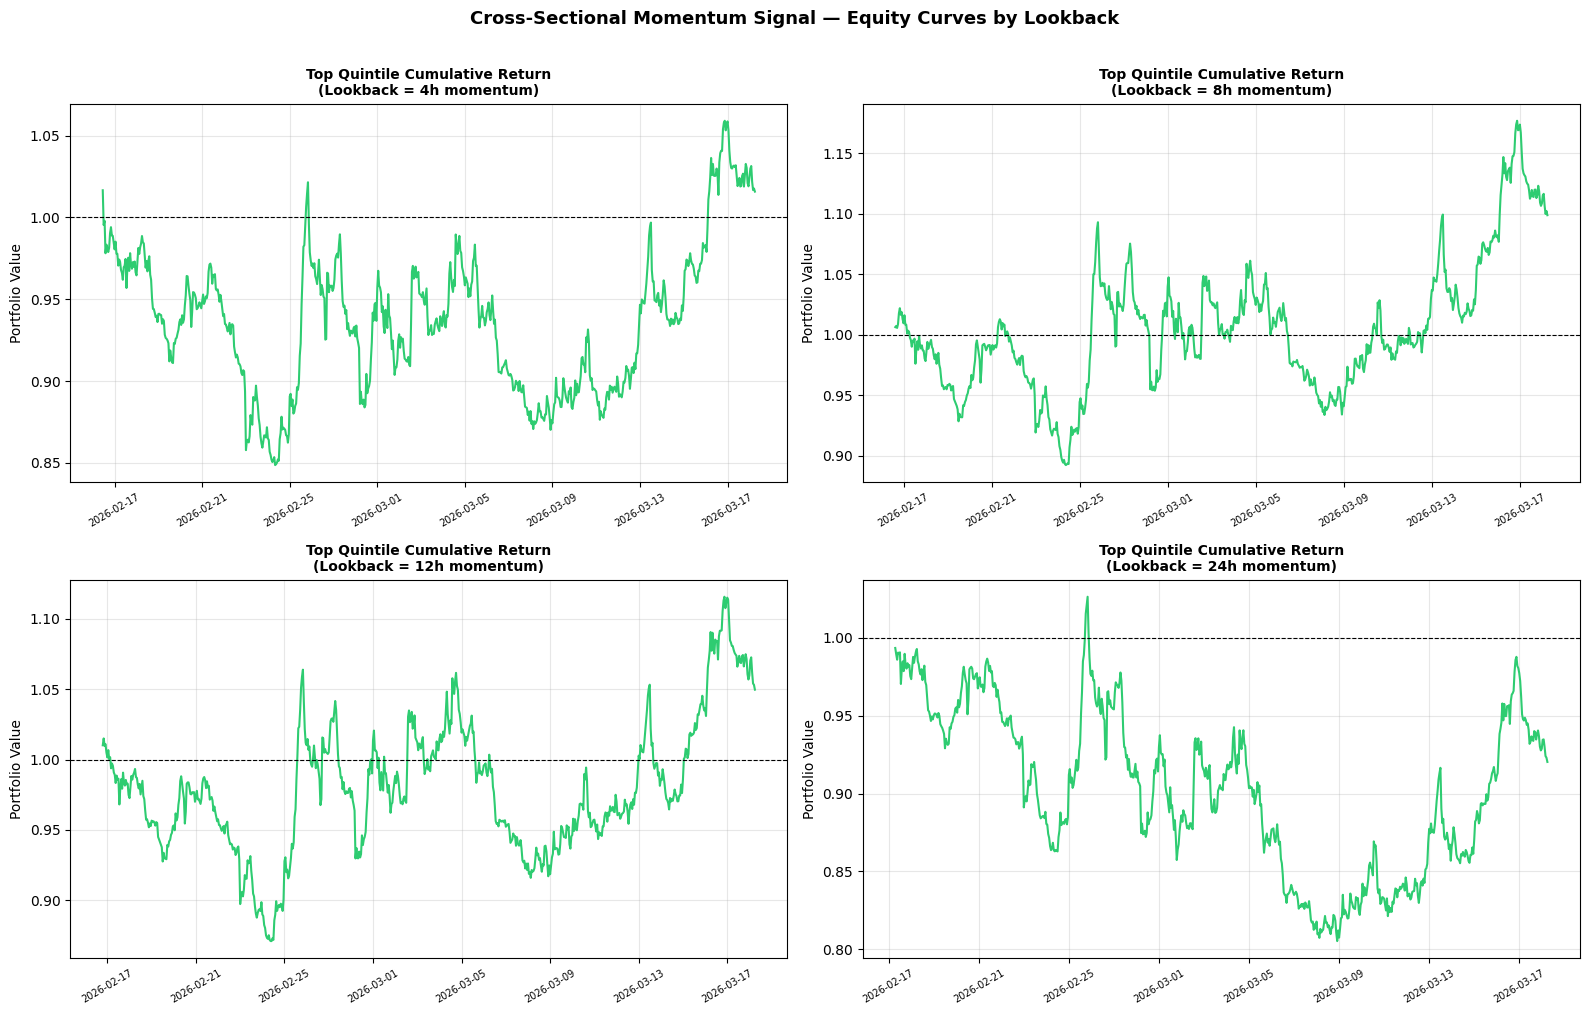

In [18]:
# Plot the L/S spread for each lookback
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, lb in enumerate(LOOKBACK_HOURS):
    pivot_close = (
        hourly_df[hourly_df['symbol'].isin(tradeable_coins)]
        .pivot_table(index='ts_hour', columns='symbol', values='close')
        .sort_index()
    )
    mom   = pivot_close.pct_change(lb)
    fwd   = pivot_close.pct_change(1).shift(-1)
    ranks = mom.rank(axis=1, pct=True)
    top_q = fwd.where(ranks >= 0.8).mean(axis=1)

    cumret = (1 + top_q.dropna()).cumprod()
    axes[i].plot(cumret.index, cumret.values, color='#2ecc71', linewidth=1.5)
    axes[i].axhline(1.0, color='black', linewidth=0.8, linestyle='--')
    axes[i].set_title(f'Top Quintile Cumulative Return\n(Lookback = {lb}h momentum)', fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Portfolio Value')
    axes[i].tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle('Cross-Sectional Momentum Signal — Equity Curves by Lookback', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../data/eda_momentum_preview.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Data Gap Analysis

Identify **where** gaps occur in the 1m data — important for live signal continuity.

In [19]:
# For each coin, find the largest timestamp gap in 1m data
gap_results = []

# Pull timestamps per coin from DuckDB — efficient
for sym in tradeable_coins:
    ts_series = con.execute("""
        SELECT ts FROM ohlcv
        WHERE symbol = ? AND interval = '1m'
        ORDER BY ts
    """, [sym]).df()['ts']
    
    ts_series = pd.to_datetime(ts_series, utc=True)
    diffs = ts_series.diff().dt.total_seconds() / 60  # gap in minutes
    diffs = diffs.dropna()
    
    gap_results.append({
        'symbol'       : sym,
        'max_gap_min'  : diffs.max(),
        'gaps_gt_5min' : (diffs > 5).sum(),
        'gaps_gt_60min': (diffs > 60).sum(),
        'gaps_gt_4h'   : (diffs > 240).sum(),
    })

gap_df = pd.DataFrame(gap_results).sort_values('max_gap_min', ascending=False)
print('Data gap summary (tradeable coins):')
display(gap_df.to_string(index=False))

Data gap summary (tradeable coins):


'     symbol  max_gap_min  gaps_gt_5min  gaps_gt_60min  gaps_gt_4h\n   MIRA-USD          1.0             0              0           0\n   SHIB-USD          1.0             0              0           0\n    CFX-USD          1.0             0              0           0\n  FLOKI-USD          1.0             0              0           0\n   WLFI-USD          1.0             0              0           0\n    WLD-USD          1.0             0              0           0\n    CRV-USD          1.0             0              0           0\n    UNI-USD          1.0             0              0           0\n   ONDO-USD          1.0             0              0           0\n    ADA-USD          1.0             0              0           0\n   DOGE-USD          1.0             0              0           0\n    SOL-USD          1.0             0              0           0\n   AVAX-USD          1.0             0              0           0\n    POL-USD          1.0             0              0        

## 12. Final Tradeable Universe Summary

In [32]:
# Merge everything into one master summary
summary = (
    merged
    .merge(vol_df[['symbol','hourly_vol_pct','daily_vol_pct','avg_atr_pct_fmt','sharpe_raw']], on='symbol', how='left')
    .merge(gap_df[['symbol','max_gap_min','gaps_gt_60min']], on='symbol', how='left')
)
summary_clean = summary[summary['fully_tradeable']].copy()
summary_clean = summary_clean.sort_values('avg_daily_vol_usd_M', ascending=False).reset_index(drop=True)
summary_clean.index += 1  # 1-indexed

In [33]:
summary_clean

,symbol,hourly_vol,mean_ret,skewness,kurtosis,avg_atr_pct,max_1h_drawdown,annualized_vol,daily_vol,hourly_vol_pct_x,...,liquid,completeness_pct,tradeable,fully_tradeable,hourly_vol_pct_y,daily_vol_pct_y,avg_atr_pct_fmt_y,sharpe_raw_y,max_gap_min,gaps_gt_60min
1,BTC-USD,0.005740,0.000104,-0.092741,6.760162,0.008386,-0.036881,0.537238,0.028120,0.5740,...,True,100.00,True,True,0.5740,2.81,0.839,1.70,1.0,0.0
2,ETH-USD,0.007138,0.000226,0.146730,5.436552,0.010725,-0.041198,0.668093,0.034970,0.7138,...,True,100.01,True,True,0.7138,3.50,1.073,2.97,1.0,0.0
3,SOL-USD,0.007819,0.000141,0.103777,5.971393,0.011845,-0.050287,0.731846,0.038307,0.7819,...,True,100.02,True,True,0.7819,3.83,1.185,1.68,1.0,0.0
4,XRP-USD,0.006953,0.000054,0.334272,4.695824,0.010259,-0.039912,0.650728,0.034061,0.6953,...,True,100.03,True,True,0.6953,3.41,1.026,0.73,1.0,0.0
5,DOGE-USD,0.007989,-0.000032,0.150306,4.651521,0.011881,-0.043368,0.747695,0.039136,0.7989,...,True,100.01,True,True,0.7989,3.91,1.188,-0.37,1.0,0.0
6,BNB-USD,0.005128,0.000129,-0.436727,5.590577,0.007490,-0.033377,0.479915,0.025120,0.5128,...,True,100.00,True,True,0.5128,2.51,0.749,2.35,1.0,0.0
7,PAXG-USD,0.003070,-0.000004,-0.777536,7.766294,0.004146,-0.020426,0.287341,0.015040,0.3070,...,True,100.01,True,True,0.3070,1.50,0.415,-0.13,1.0,0.0
8,ZEC-USD,0.011123,-0.000033,0.217875,3.942198,0.017058,-0.066156,1.041050,0.054491,1.1123,...,True,100.03,True,True,1.1123,5.45,1.706,-0.28,1.0,0.0
9,PEPE-USD,0.009293,-0.000274,-0.014291,2.493019,0.016238,-0.042200,0.869765,0.045526,0.9293,...,True,100.01,True,True,0.9293,4.55,1.624,-2.76,1.0,0.0
10,SUI-USD,0.009005,0.000092,0.009283,5.125492,0.013447,-0.052504,0.842855,0.044117,0.9005,...,True,100.02,True,True,0.9005,4.41,1.345,0.96,1.0,0.0


In [37]:
display_cols = [
    'symbol', 'avg_daily_vol_usd_M', 'daily_vol_pct_x',
    'avg_atr_pct_fmt_x', 'completeness_pct', 'max_gap_min', 'sharpe_raw_x'
]

print(f'╔══════════════════════════════════════════════════════════════╗')
print(f'  FINAL TRADEABLE UNIVERSE: {len(summary_clean)} COINS')
print(f'╚══════════════════════════════════════════════════════════════╝')
print()
display(summary_clean[display_cols].rename(columns={
    'avg_daily_vol_usd_M' : 'Avg Daily Vol ($M)',
    'daily_vol_pct_x'       : 'Daily Vol (%)',
    'avg_atr_pct_fmt_x'     : 'ATR % (14h)',
    'completeness_pct'    : 'Data Completeness (%)',
    'max_gap_min'         : 'Max Gap (min)',
    'sharpe_raw_x'          : 'Naive Sharpe',
}).to_string())

# Save the list for use by signal module
summary_clean['symbol'].to_csv('../data/tradeable_universe.csv', index=False)
print(f'\nSaved tradeable universe to ../data/tradeable_universe.csv')

╔══════════════════════════════════════════════════════════════╗
  FINAL TRADEABLE UNIVERSE: 58 COINS
╚══════════════════════════════════════════════════════════════╝



'         symbol  Avg Daily Vol ($M)  Daily Vol (%)  ATR % (14h)  Data Completeness (%)  Max Gap (min)  Naive Sharpe\n1       BTC-USD             1608.12           2.81        0.839                 100.00            1.0          1.70\n2       ETH-USD              885.34           3.50        1.073                 100.01            1.0          2.97\n3       SOL-USD              304.26           3.83        1.185                 100.02            1.0          1.68\n4       XRP-USD              196.66           3.41        1.026                 100.03            1.0          0.73\n5      DOGE-USD               96.36           3.91        1.188                 100.01            1.0         -0.37\n6       BNB-USD               86.10           2.51        0.749                 100.00            1.0          2.35\n7      PAXG-USD               81.08           1.50        0.415                 100.01            1.0         -0.13\n8       ZEC-USD               50.08           5.45        1.706


Saved tradeable universe to ../data/tradeable_universe.csv


In [27]:
# Print key EDA takeaways as a clean summary
print('='*60)
print('EDA KEY FINDINGS')
print('='*60)
print(f'Total coins profiled      : {len(SYMBOLS)}')
print(f'Coins passing all filters : {len(summary_clean)}')
print()
print(f'Most liquid               : {liquidity_df.iloc[0]["symbol"].replace("-USD","")} (${liquidity_df.iloc[0]["avg_daily_vol_usd_M"]:.1f}M/day)')
print(f'Highest volatility        : {vol_df.iloc[0]["symbol"].replace("-USD","")} ({vol_df.iloc[0]["daily_vol_pct"]:.2f}% daily vol)')
print(f'Best naive Sharpe         : {vol_df.sort_values("sharpe_raw",ascending=False).iloc[0]["symbol"].replace("-USD","")} ({vol_df.sort_values("sharpe_raw",ascending=False).iloc[0]["sharpe_raw"]:.2f})')
print(f'Universe avg correlation  : {flat_corrs.mean():.3f}')
print(f'Optimal rebalance         : 1h (next notebook: signals)')
print()
print('Next step: research/04_signal_development.ipynb')
print('='*60)

EDA KEY FINDINGS
Total coins profiled      : 67
Coins passing all filters : 58

Most liquid               : BTC ($1608.1M/day)
Highest volatility        : MIRA (9.48% daily vol)
Best naive Sharpe         : TRX (4.97)
Universe avg correlation  : 0.564
Optimal rebalance         : 1h (next notebook: signals)

Next step: research/04_signal_development.ipynb


In [23]:
con.close()
print('DuckDB connection closed.')

DuckDB connection closed.
